In [1]:
import pandas as pd 

df = pd.read_csv("../data/sales_dataset.csv")
df.head(10)

,index,Date,Year,Month,Customer Age,Customer Gender,Country,State,Product Category,Sub Category,Quantity,Unit Cost,Unit Price,Cost,Revenue,Column1
0,0,2/19/2016,2016.0,February,29.0,F,United States,Washington,Accessories,Tires and Tubes,1.0,80.00,109.000000,80.0,109.0,NaN
1,1,2/20/2016,2016.0,February,29.0,F,United States,Washington,Clothing,Gloves,2.0,24.50,28.500000,49.0,57.0,NaN
2,2,2/27/2016,2016.0,February,29.0,F,United States,Washington,Accessories,Tires and Tubes,3.0,3.67,5.000000,11.0,15.0,NaN
3,3,3/12/2016,2016.0,March,29.0,F,United States,Washington,Accessories,Tires and Tubes,2.0,87.50,116.500000,175.0,233.0,NaN
4,4,3/12/2016,2016.0,March,29.0,F,United States,Washington,Accessories,Tires and Tubes,3.0,35.00,41.666667,105.0,125.0,NaN
5,5,4/8/2016,2016.0,April,29.0,F,United States,Washington,Accessories,Tires and Tubes,1.0,66.00,78.000000,66.0,78.0,NaN
6,6,4/17/2016,2016.0,April,29.0,F,United States,Washington,Accessories,Tires and Tubes,2.0,52.00,60.000000,104.0,120.0,NaN
7,7,4/17/2016,2016.0,April,29.0,F,United States,Washington,Accessories,Tires and Tubes,1.0,60.00,68.000000,60.0,68.0,NaN
8,8,6/22/2016,2016.0,June,29.0,F,United States,Washington,Accessories,Tires and Tubes,2.0,8.00,10.000000,16.0,20.0,NaN
9,9,6/22/2016,2016.0,June,29.0,F,United States,Washington,Accessories,Tires and Tubes,2.0,2.50,3.000000,5.0,6.0,NaN


In [2]:
df_sales = pd.DataFrame({
    "Date" : df["Date"],
    "Sales" : df["Revenue"]
})

df_sales.head(10)

,Date,Sales
0,2/19/2016,109.0
1,2/20/2016,57.0
2,2/27/2016,15.0
3,3/12/2016,233.0
4,3/12/2016,125.0
5,4/8/2016,78.0
6,4/17/2016,120.0
7,4/17/2016,68.0
8,6/22/2016,20.0
9,6/22/2016,6.0


In [3]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34867 entries, 0 to 34866
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    34866 non-null  object 
 1   Sales   34867 non-null  float64
dtypes: float64(1), object(1)
memory usage: 544.9+ KB


In [13]:
df_sales.duplicated().sum()

np.int64(1782)

In [14]:
df_sales.shape

(34867, 2)

In [15]:
df_sales.drop_duplicates()
df_sales.shape

(34867, 2)

In [4]:
df_sales.isnull().sum()

Date     1
Sales    0
dtype: int64

In [17]:
df_sales_clean = df_sales.dropna()

In [18]:
df_sales_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 34866 entries, 0 to 34865
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    34866 non-null  object 
 1   Sales   34866 non-null  float64
dtypes: float64(1), object(1)
memory usage: 817.2+ KB


In [21]:
# Outlier detection
# IQR

Q1 = df_sales_clean["Sales"].quantile(0.25)
Q3 = df_sales_clean["Sales"].quantile(0.75)
IQR = Q3 - Q1

lowest = Q1 - 1.5*IQR
highest = Q3 + 1.5*IQR

outliers = df_sales_clean[(df_sales_clean["Sales"] < lowest) | (df_sales_clean["Sales"] > highest)]

df_sales_new = df_sales_clean[(df_sales_clean["Sales"] > lowest) & (df_sales_clean["Sales"] < highest)]

outliers.shape

(2801, 2)

In [22]:
df_sales_new.shape

(32062, 2)

In [24]:
df_sales_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32062 entries, 0 to 34865
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    32062 non-null  object 
 1   Sales   32062 non-null  float64
dtypes: float64(1), object(1)
memory usage: 751.5+ KB


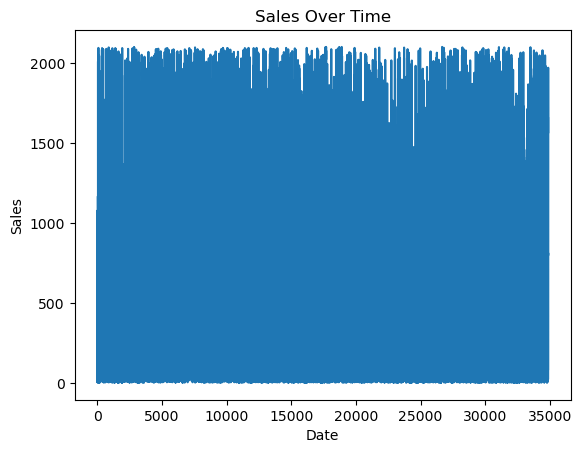

In [26]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df_sales_new["Sales"])
plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

C:\Users\Rishabh Singh\AppData\Local\Temp\ipykernel_12248\1788879101.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sales_new["MA_7"] = df_sales_new["Sales"].rolling(window=7).mean()


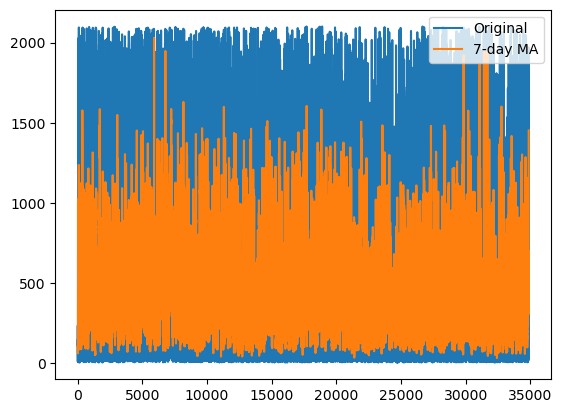

In [27]:
df_sales_new["MA_7"] = df_sales_new["Sales"].rolling(window=7).mean()

plt.figure()
plt.plot(df_sales_new["Sales"], label="Original")
plt.plot(df_sales_new["MA_7"], label="7-day MA")
plt.legend()
plt.show()

In [29]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df_sales_new["Sales"])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -29.57125879826853
p-value: 0.0


In [31]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df_sales_new["Sales"], order=(5,1,0))  # (p,d,q)
model_fit = model.fit()

print(model_fit.summary())

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                32062
Model:                 ARIMA(5, 1, 0)   Log Likelihood             -244662.423
Date:                Fri, 20 Feb 2026   AIC                         489336.847
Time:                        20:53:11   BIC                         489387.099
Sample:                             0   HQIC                        489352.920
                              - 32062                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7373      0.005   -154.476      0.000      -0.747      -0.728
ar.L2         -0.5440      0.006    -91.690      0.000      -0.556      -0.532
ar.L3         -0.3874      0.006    -62.059      0.0

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


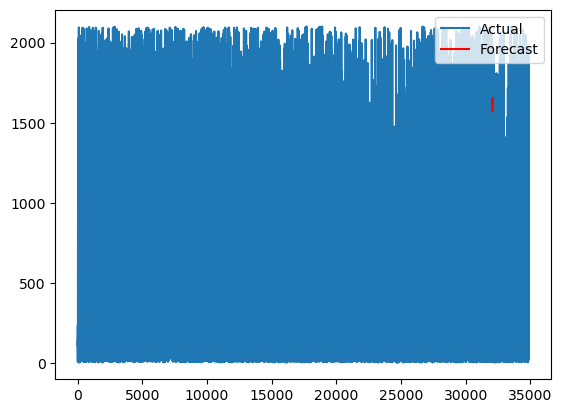

In [32]:
forecast = model_fit.forecast(steps=30)

plt.figure()
plt.plot(df_sales_new["Sales"], label="Actual")
plt.plot(forecast, label="Forecast", color="red")
plt.legend()
plt.show()

In [33]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Example: split data
train = df_sales_new[:150]
test = df_sales_new[150:]

model = ARIMA(train["Sales"], order=(5,1,0))
model_fit = model.fit()

pred = model_fit.forecast(steps=len(test))

rmse = np.sqrt(mean_squared_error(test["Sales"], pred))
print("RMSE:", rmse)

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results 

RMSE: 621.3560433403715
